# Application de CLAHE sur des radiographies thoraciques

**CLAHE** (Contrast Limited Adaptive Histogram Equalization) est une technique d'amélioration du contraste local qui divise l'image en petites régions (tuiles) et applique une égalisation d'histogramme adaptative avec limitation du contraste.

Cette approche est particulièrement utile pour les images médicales comme les radiographies thoraciques, où les détails subtils peuvent être perdus à cause d'un faible contraste.

## 1. Import des bibliothèques

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

random.seed(42)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

## 2. Chargement d'images échantillons

On sélectionne 2 images aléatoires de chaque catégorie (COVID, Lung_Opacity, Normal, Viral Pneumonia).

In [11]:
BASE_PATH = "../data/processed/raw_dataset_without_masks"
CATEGORIES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
N_SAMPLES = 2

# Charger des images échantillons par catégorie
samples = {}
for cat in CATEGORIES:
    cat_path = os.path.join(BASE_PATH, cat)
    all_files = [f for f in os.listdir(cat_path) if f.endswith(".png")]
    selected = random.sample(all_files, min(N_SAMPLES, len(all_files)))
    samples[cat] = []
    for fname in selected:
        img = cv2.imread(os.path.join(cat_path, fname), cv2.IMREAD_GRAYSCALE)
        samples[cat].append((fname, img))
        print(f"  {cat}/{fname} — shape: {img.shape}, dtype: {img.dtype}")

print(f"\n{sum(len(v) for v in samples.values())} images chargées au total.")

  COVID/COVID-389.png — shape: (299, 299), dtype: uint8
  COVID/COVID-363.png — shape: (299, 299), dtype: uint8
  Lung_Opacity/Lung_Opacity-3198.png — shape: (299, 299), dtype: uint8
  Lung_Opacity/Lung_Opacity-2971.png — shape: (299, 299), dtype: uint8
  Normal/Normal-5868.png — shape: (299, 299), dtype: uint8
  Normal/Normal-4137.png — shape: (299, 299), dtype: uint8
  Viral Pneumonia/Viral Pneumonia-497.png — shape: (299, 299), dtype: uint8
  Viral Pneumonia/Viral Pneumonia-266.png — shape: (299, 299), dtype: uint8

8 images chargées au total.


## 3. Affichage des images originales

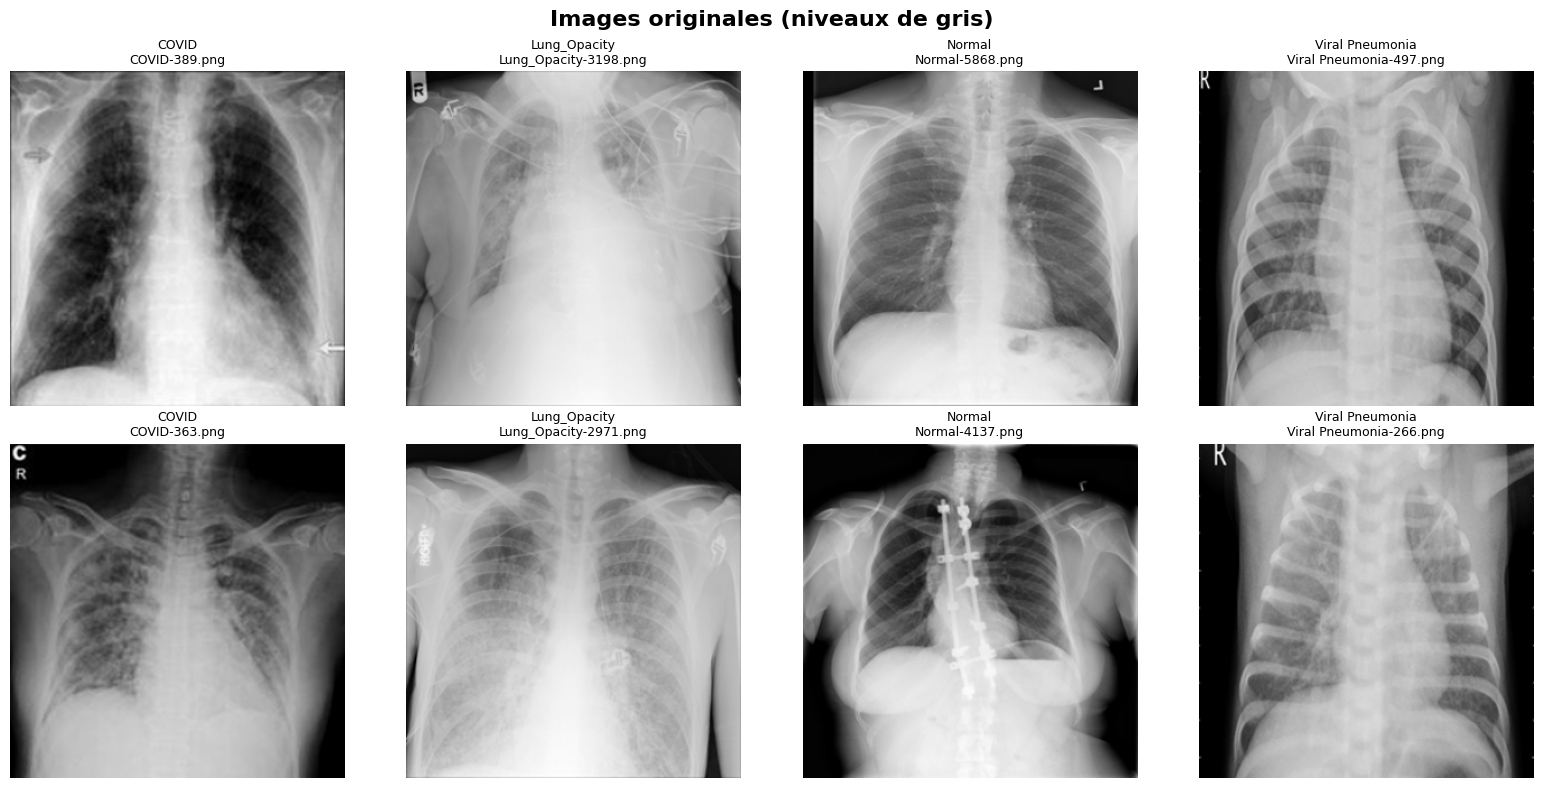

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Images originales (niveaux de gris)", fontsize=16, fontweight='bold')

for col, cat in enumerate(CATEGORIES):
    for row in range(N_SAMPLES):
        fname, img = samples[cat][row]
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(f"{cat}\n{fname}", fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## 4. Application de CLAHE — Comparaison Avant / Après

On applique CLAHE avec `clipLimit=2.0` et `tileGridSize=(8, 8)` sur chaque image, puis on compare côte à côte l'original et le résultat.

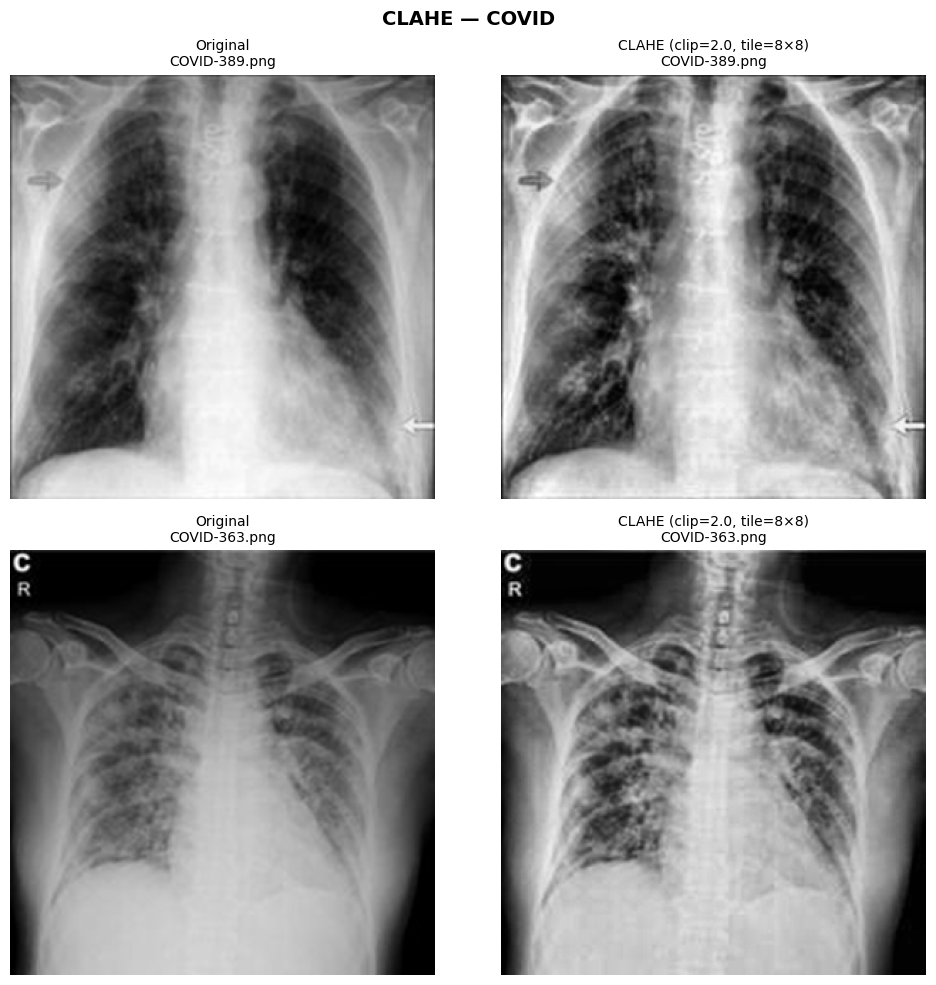

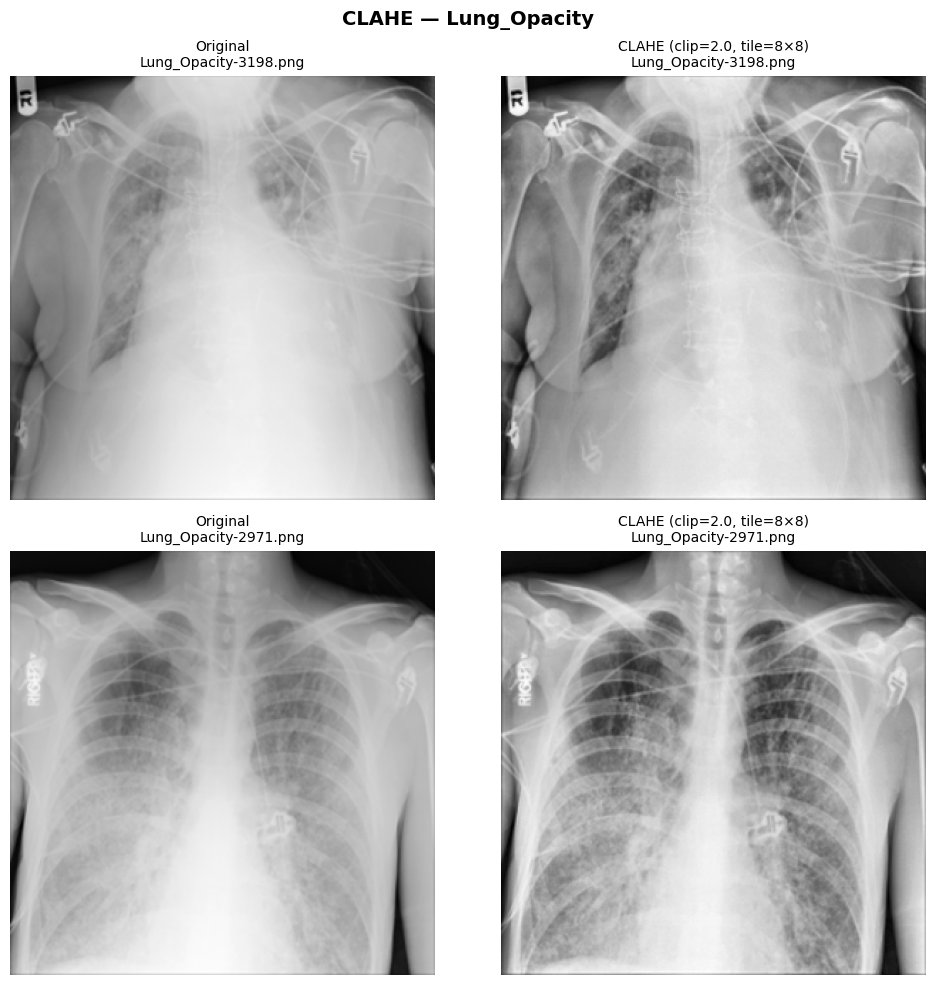

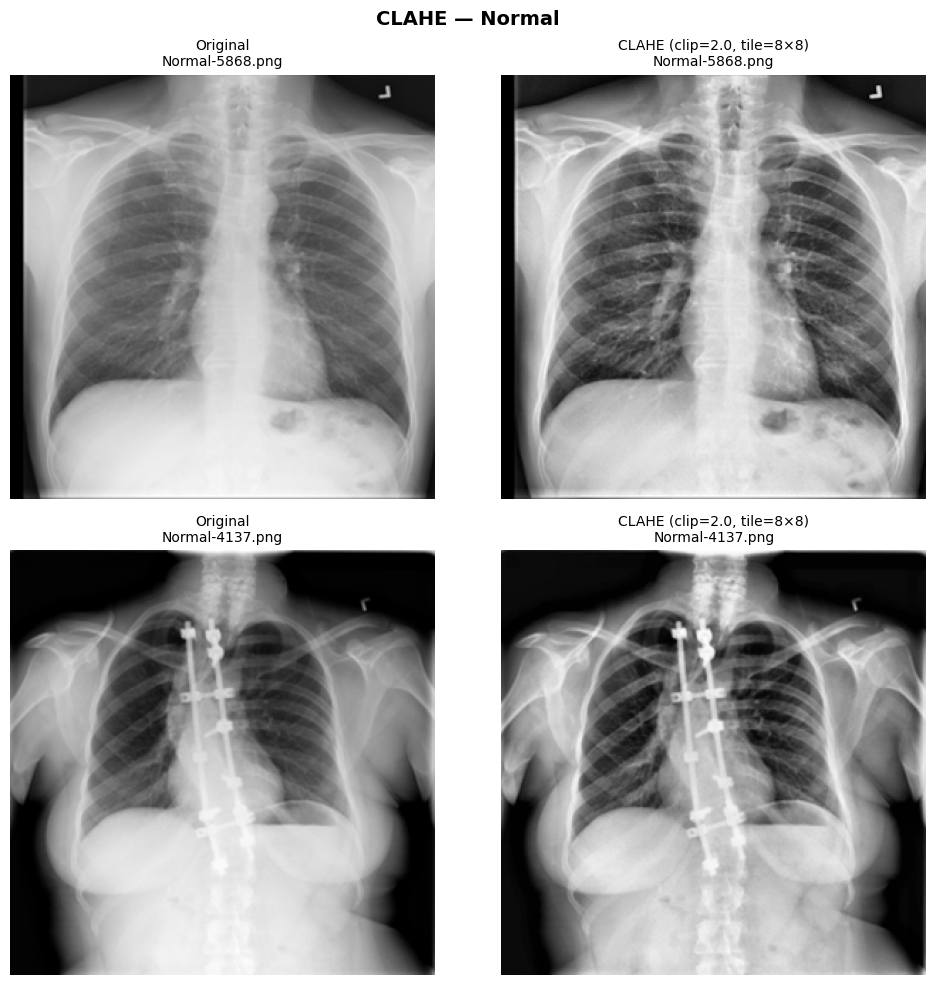

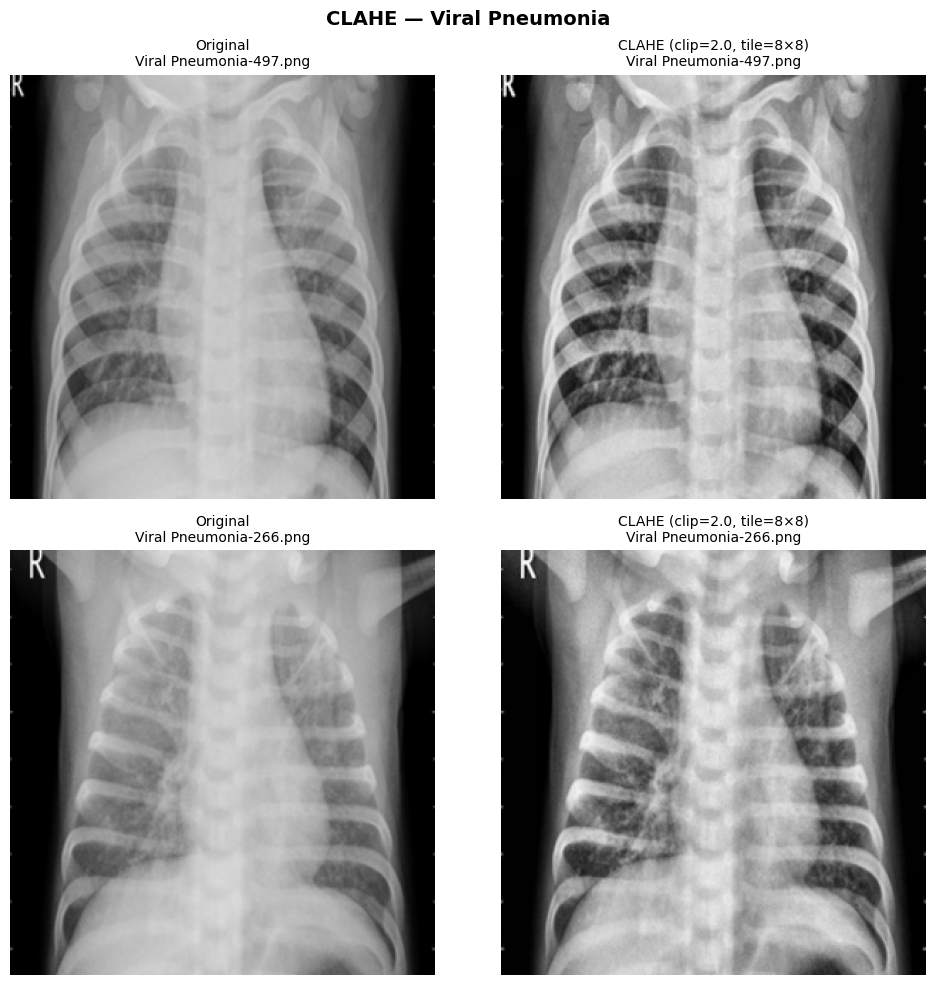

In [13]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

for cat in CATEGORIES:
    fig, axes = plt.subplots(N_SAMPLES, 2, figsize=(10, 5 * N_SAMPLES))
    fig.suptitle(f"CLAHE — {cat}", fontsize=14, fontweight='bold')

    for row, (fname, img) in enumerate(samples[cat]):
        img_clahe = clahe.apply(img)

        axes[row, 0].imshow(img, cmap='gray')
        axes[row, 0].set_title(f"Original\n{fname}", fontsize=10)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(img_clahe, cmap='gray')
        axes[row, 1].set_title(f"CLAHE (clip=2.0, tile=8×8)\n{fname}", fontsize=10)
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()

## 5. Influence du paramètre `clipLimit`

Le paramètre `clipLimit` contrôle l'amplification maximale du contraste. Plus la valeur est élevée, plus le contraste est amplifié. On teste ici plusieurs valeurs sur une même image.

In [ ]:
# Utiliser la première image COVID pour la démo
demo_fname, demo_img = samples["COVID"][0]
clip_limits = [1.0, 2.0, 4.0, 8.0]

fig, axes = plt.subplots(1, len(clip_limits) + 1, figsize=(18, 4))
fig.suptitle(f"Effet du clipLimit sur {demo_fname}", fontsize=14, fontweight='bold')

# Original
axes[0].imshow(demo_img, cmap='gray')
axes[0].set_title("Original", fontsize=11)
axes[0].axis('off')

# Différents clipLimits
for i, cl in enumerate(clip_limits):
    clahe_var = cv2.createCLAHE(clipLimit=cl, tileGridSize=(8, 8))
    img_enhanced = clahe_var.apply(demo_img)
    axes[i + 1].imshow(img_enhanced, cmap='gray')
    axes[i + 1].set_title(f"clipLimit={cl}", fontsize=11)
    axes[i + 1].axis('off')

plt.tight_layout()
plt.show()